
# Notebook 02 — Analyse multidimensionnelle : typologie des opérations

**Copilote Financier — Groupe Angelotti | Mémoire M2 MIASHS**

Objectif métier (besoin **B-A3**, `docs/03_besoins_metier.md`) : comparer
chaque opération immobilière à ses « voisines » de **profil de coûts**
similaire, pour objectiver les revues de gestion — et construire une
**typologie** des opérations réutilisable par les axes A (risque de marge)
et C (prix).

Démarche, dans l'ordre du module d'analyse de données multidimensionnelle
et de classification non supervisée :

1. matrice des **profils de coûts** (parts des postes budgétaires) et
   standardisation ;
2. **ACP à la main** (valeurs propres / vecteurs propres de la covariance,
   multiplicateur de Lagrange) ;
3. **SVD** $X = U\Sigma V^\top$ et pont avec la régularisation Ridge
   (*regularization.pdf*, p. 26) ;
4. **similarité cosinus** entre opérations
   (*simialrity_based_text_retrieval*, slide 12) — le comparateur du
   copilote ;
5. **K-moyennes** par l'algorithme de Lloyd, critère du coude, silhouette,
   Davies-Bouldin (*coursClassif-5-Clustering*, slides 8-25) ;
6. **CAH** avec la distance de Ward (slide 17) et comparaison des
   partitions ;
7. interprétation métier des clusters (évaluation externe, slide 29) ;
8. synthèse.

L'ACP et le multiplicateur de Lagrange sont absents des supports de cours :
nous les introduisons d'après Azencott, *Introduction au Machine Learning*
(ouvrage de référence des cours de classification, cité slide 1 du cours de
clustering), en les raccrochant au SVD du cours de régularisation et à la
condition d'optimalité $\nabla f = 0$ du cours d'optimisation.


In [1]:
# --- Amorçage : exécution locale ou Google Colab ---
import pathlib, subprocess, sys

racine = pathlib.Path.cwd()
while not (racine / "src" / "nettoyage.py").exists() and racine != racine.parent:
    racine = racine.parent
if not (racine / "src" / "nettoyage.py").exists():  # environnement Colab vierge
    subprocess.run(["git", "clone", "-b", "claude/copilote-financier-angelotti-72c614",
                    "https://github.com/yzasmin/MemoireM2S2.git"], check=True)
    racine = pathlib.Path.cwd() / "MemoireM2S2"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                    str(racine / "requirements.txt")], check=True)

sys.path.insert(0, str(racine / "src"))
import base_sql

if not base_sql.DB.exists():  # reconstruit data/copilote.db depuis donnéebrut/
    base_sql.construire_base()
DB = base_sql.DB
print("Base prête :", DB)


Base prête : /home/user/MemoireM2S2/data/copilote.db



## 1. La matrice $X$ des profils de coûts

Comparer des opérations de 2 M€ et de 50 M€ sur leurs montants n'aurait pas
de sens : c'est la **structure** du budget qui signe le type d'opération.
Pour chaque opération, on calcule donc la **part de chaque poste de
dépenses de niveau 1** (`poste_niv1` de la table `budget`, sens `D`) dans
le total des dépenses budgétées : chaque ligne de $X$ est un profil qui
somme à 1 (données dites *compositionnelles*).

Deux choix de périmètre, motivés par la sensibilité des K-moyennes aux
données aberrantes (*coursClassif-5-Clustering*, slide 27) :

- on écarte les opérations **embryonnaires** (dépenses budgétées < 1 M€ ou
  recettes nulles) : ce sont des études dont le budget se réduit à des
  honoraires — elles formaient des clusters singletons dans nos essais ;
- on regroupe en `AUTRES FRAIS` les quatre postes qui pèsent ensemble moins
  de 0,4 % des dépenses du groupe (assurances, honoraires divers,
  communication/marketing, frais de structure) : standardiser une colonne
  quasi nulle revient à amplifier du bruit.


In [2]:

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import theme_viz
theme_viz.appliquer()

con = sqlite3.connect(DB)
dep = pd.read_sql("""
    SELECT id_operation, poste_niv1, SUM(budget_ht) AS budget_ht
    FROM budget WHERE sens = 'D'
    GROUP BY id_operation, poste_niv1
""", con)
marge = pd.read_sql("SELECT * FROM v_marge_operation", con).set_index("id_operation")
ops = pd.read_sql(
    "SELECT id_operation, libelle, agence, activite, type_operation, statut "
    "FROM operations", con).set_index("id_operation")

brut = dep.pivot_table(index="id_operation", columns="poste_niv1",
                       values="budget_ht", fill_value=0.0)
poids = brut.sum() / brut.sum().sum()
print("Poids de chaque poste dans les dépenses budgétées du groupe :")
print((100 * poids.sort_values(ascending=False)).round(2).to_string())

petits = ["ASSURANCES", "HONORAIRES DIVERS", "COMMUNICATION/MARKETING",
          "FRAIS DE STRUCTURE"]
print(f"\nPoids cumulé des 4 petits postes regroupés : {100*poids[petits].sum():.2f} %")
brut["AUTRES FRAIS"] = brut[petits].sum(axis=1)
brut = brut.drop(columns=petits)

mures = marge[(marge["recettes_budget"] > 0) & (marge["depenses_budget"] >= 1e6)]
brut = brut.loc[brut.index.intersection(mures.index)]
P = brut.div(brut.sum(axis=1), axis=0)          # profils : chaque ligne somme à 1
print(f"\nOpérations : {len(marge)} au budget -> {len(P)} retenues "
      f"({len(marge) - len(P)} embryonnaires écartées)")
print(f"Matrice des profils P : {P.shape[0]} opérations x {P.shape[1]} postes")
P.head(3).round(3)


Poids de chaque poste dans les dépenses budgétées du groupe :
poste_niv1
CONSTRUCTION               44.64
FONCIER                    18.16
VRD                        10.91
GESTION                     8.87
COMMERCIALISATION           8.39
HONORAIRES TECHNIQUES       6.04
TAXES                       1.79
FRAIS FINANCIERS            0.87
HONORAIRES DIVERS           0.14
ASSURANCES                  0.13
COMMUNICATION/MARKETING     0.05
FRAIS DE STRUCTURE          0.00

Poids cumulé des 4 petits postes regroupés : 0.33 %

Opérations : 267 au budget -> 223 retenues (44 embryonnaires écartées)
Matrice des profils P : 223 opérations x 9 postes


poste_niv1,COMMERCIALISATION,CONSTRUCTION,FONCIER,FRAIS FINANCIERS,GESTION,HONORAIRES TECHNIQUES,TAXES,VRD,AUTRES FRAIS
id_operation,,,,,,,,,
1,0.099,0.000,0.320,0.016,0.099,0.030,0.003,0.415,0.019
2,0.000,0.658,0.105,0.000,0.093,0.077,0.000,0.068,0.000
3,0.000,0.676,0.118,0.000,0.092,0.070,0.000,0.044,0.000



### Standardisation — pourquoi elle est indispensable ici

Toutes les méthodes de ce notebook (ACP, cosinus, K-moyennes, CAH)
reposent sur la **distance euclidienne** du cours de clustering (slide 5) :
$d(x,y) = \|x-y\|_2 = \sqrt{\sum_{i=1}^d (x_i - y_i)^2}$. Cette distance
additionne les écarts de toutes les dimensions **sans les hiérarchiser** :
la part de `CONSTRUCTION` (écart-type ≈ 0,29) écraserait celle des
`FRAIS FINANCIERS` (écart-type ≈ 0,02), et la typologie ne « verrait » que
les deux ou trois gros postes. Le cours propose la distance de
**Mahalanobis** $d(x,y) = \sqrt{(x-y)^\top\Sigma^{-1}(x-y)}$ (slide 5,
$\Sigma$ : matrice de variance-covariance empirique) qui neutralise
échelles *et* corrélations ; nous retenons sa version diagonale, la
**standardisation** $x_{ij} \leftarrow \frac{x_{ij} - \bar{x}_j}{s_j}$
(pratique standard, Azencott), qui neutralise les échelles tout en laissant
l'ACP analyser les corrélations — c'est précisément son travail.


In [3]:

print("Écart-type des parts, AVANT standardisation :")
print(P.std(ddof=1).sort_values(ascending=False).round(3).to_string())

X = (P - P.mean()) / P.std(ddof=1)              # standardisation colonne par colonne
X_np = X.to_numpy()
n, p = X_np.shape
print(f"\nX standardisée : n = {n} opérations, p = {p} postes "
      f"(moyennes ~0, écarts-types = 1)")


Écart-type des parts, AVANT standardisation :
poste_niv1
CONSTRUCTION             0.292
VRD                      0.152
FONCIER                  0.143
COMMERCIALISATION        0.056
TAXES                    0.051
GESTION                  0.030
HONORAIRES TECHNIQUES    0.023
FRAIS FINANCIERS         0.019
AUTRES FRAIS             0.008

X standardisée : n = 223 opérations, p = 9 postes (moyennes ~0, écarts-types = 1)



**Lecture.** Les dépenses du groupe sont dominées par `CONSTRUCTION`
(≈ 45 %), `FONCIER` (≈ 18 %) et `VRD` (≈ 11 %) — mais c'est la
**dispersion** entre opérations qui nous intéresse : la part de
construction varie énormément (écart-type 0,29), signature attendue de la
double activité du groupe (promotion immobilière vs aménagement de
terrains). Après standardisation, chaque poste contribue à égalité à la
distance entre deux opérations.



## 2. ACP « à la main » : valeurs propres de la covariance

L'ACP est absente des supports de cours (seule l'ACM est mentionnée pour le
qualitatif, *coursClassif-5-Clustering* slide 6) ; nous suivons Azencott,
*Introduction au Machine Learning*, avec les notations du cours
d'optimisation.

**Le problème.** Trouver la direction $v \in \mathbb{R}^p$, $\|v\| = 1$,
qui **maximise la variance des données projetées**. Pour $X$ centrée, la
variance de la projection $Xv$ vaut
$\frac{1}{n-1}\|Xv\|^2 = v^\top \Sigma v$, où
$\Sigma = \frac{1}{n-1}X^\top X$ est la **matrice de covariance
empirique**. Le programme s'écrit :

$$\max_{v\in\mathbb{R}^p} v^\top \Sigma v \quad \text{sous contrainte} \quad v^\top v = 1.$$

**Résolution par multiplicateur de Lagrange** (Azencott ; l'outil est
absent des PDF de cours). On forme le **lagrangien**

$$\mathcal{L}(v, \lambda) = v^\top \Sigma v - \lambda\,(v^\top v - 1),$$

et on applique la condition nécessaire d'optimalité du cours d'optimisation
(*optim.pdf*, Théorème 1.3, p. 2 : en un extremum intérieur,
$\nabla f(x^*) = 0$) au lagrangien :

$$\nabla_v \mathcal{L} = 2\Sigma v - 2\lambda v = 0 \quad\Longleftrightarrow\quad \boxed{\Sigma v = \lambda v}.$$

Les solutions sont les **vecteurs propres** de $\Sigma$, et pour chacun la
variance projetée vaut $v^\top \Sigma v = \lambda v^\top v = \lambda$ : la
direction optimale est le vecteur propre associé à la **plus grande valeur
propre** $\lambda_1$, la deuxième composante s'obtient de même dans
l'orthogonal de la première, etc. La **part de variance expliquée** par la
composante $l$ vaut $\lambda_l / \sum_j \lambda_j$. $\Sigma$ étant
symétrique semi-définie positive (comme la Hessienne $\frac{1}{n}X^\top X$
des moindres carrés, *optim.pdf* p. 11), ses valeurs propres sont réelles
et $\geq 0$ : on les calcule avec `numpy.linalg.eigh`.


In [4]:

Xc = X_np - X_np.mean(axis=0)                    # déjà centrée, on l'assure
Sigma = (Xc.T @ Xc) / (n - 1)                    # covariance empirique Σ = XᵀX/(n-1)
valp, vecp = np.linalg.eigh(Sigma)               # diagonalisation (Σ symétrique)
ordre = np.argsort(valp)[::-1]                   # tri décroissant des valeurs propres
valp, vecp = valp[ordre], vecp[:, ordre]
for l in range(p):                               # convention de signe : poids dominant > 0
    if vecp[np.argmax(np.abs(vecp[:, l])), l] < 0:
        vecp[:, l] *= -1

part = valp / valp.sum()
tab = pd.DataFrame({"valeur propre λ": valp.round(3),
                    "part de variance": (100 * part).round(1),
                    "part cumulée": (100 * part.cumsum()).round(1)},
                   index=[f"PC{l+1}" for l in range(p)])
print(tab.to_string())
print(f"\nSomme des λ = {valp.sum():.2f} = trace(Σ) = p = {p} (variables standardisées)")
print(f"Plus petite valeur propre : {valp[-1]:.2e}")


     valeur propre λ  part de variance  part cumulée
PC1            4.011              44.6          44.6
PC2            1.478              16.4          61.0
PC3            1.105              12.3          73.3
PC4            0.831               9.2          82.5
PC5            0.672               7.5          90.0
PC6            0.421               4.7          94.7
PC7            0.304               3.4          98.0
PC8            0.177               2.0         100.0
PC9           -0.000              -0.0         100.0

Somme des λ = 9.00 = trace(Σ) = p = 9 (variables standardisées)
Plus petite valeur propre : -4.37e-16


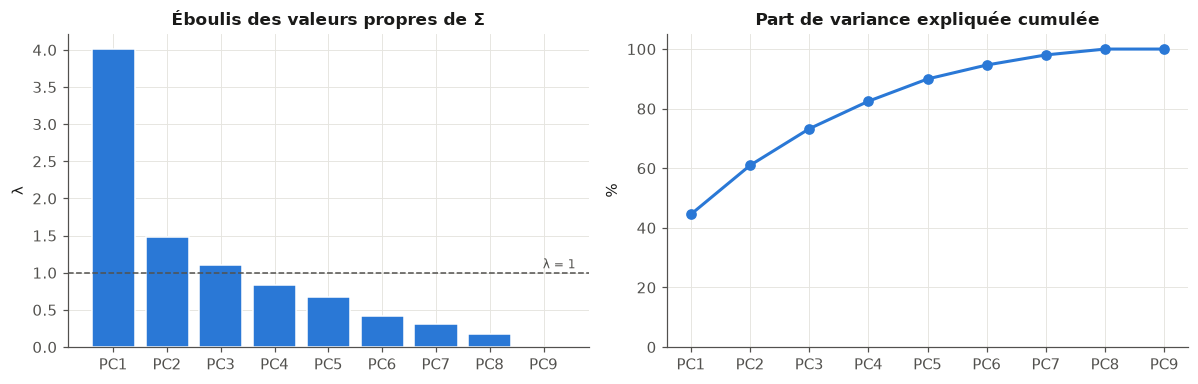

In [5]:

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.bar(tab.index, valp, color=theme_viz.SERIES[0], edgecolor="white")
a1.axhline(1, color=theme_viz.ENCRE_2, lw=1, ls="--")
a1.text(p - 0.4, 1.06, "λ = 1", ha="right", fontsize=8, color=theme_viz.ENCRE_2)
a1.set_title("Éboulis des valeurs propres de Σ")
a1.set_ylabel("λ")

a2.plot(tab.index, 100 * part.cumsum(), marker="o", color=theme_viz.SERIES[0])
a2.set_title("Part de variance expliquée cumulée")
a2.set_ylabel("%"); a2.set_ylim(0, 105)
fig.tight_layout(); plt.show()



**Lecture.** Deux composantes résument **61 %** de la variance des profils
(PC1 : 44,6 %, PC2 : 16,4 %) : le plan factoriel est une carte fidèle.
Détail instructif : la **dernière valeur propre est numériquement nulle**.
Ce n'est pas un hasard — chaque profil somme exactement à 1, donc les
9 colonnes de $X$ sont liées par une relation affine : le nuage vit dans un
hyperplan de dimension 8, et $\Sigma$ est de rang 8. L'ACP détecte
automatiquement cette contrainte compositionnelle.


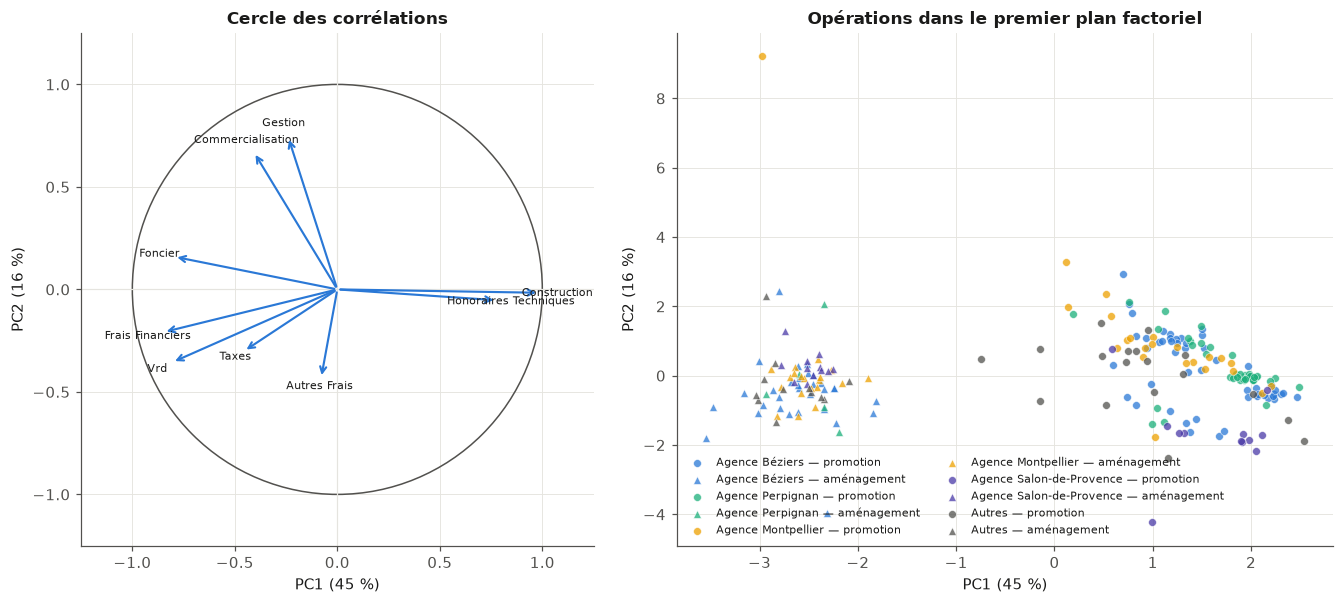

                       corr. PC1  corr. PC2
poste_niv1                                 
FRAIS FINANCIERS           -0.85      -0.21
VRD                        -0.81      -0.36
FONCIER                    -0.80       0.16
TAXES                      -0.46      -0.30
COMMERCIALISATION          -0.41       0.67
GESTION                    -0.24       0.74
AUTRES FRAIS               -0.08      -0.43
HONORAIRES TECHNIQUES       0.78      -0.05
CONSTRUCTION                0.98      -0.02


In [6]:

# Cercle des corrélations : pour X standardisée, corr(x_j, PC_l) = v_jl * sqrt(λ_l)
scores = Xc @ vecp                               # coordonnées des opérations
corr = vecp[:, :2] * np.sqrt(valp[:2])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 5.6),
                             gridspec_kw={"width_ratios": [1, 1.25]})
a1.add_patch(plt.Circle((0, 0), 1, fill=False, color=theme_viz.ENCRE_2, lw=1))
for j, nom in enumerate(P.columns):
    a1.annotate("", xy=(corr[j, 0], corr[j, 1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=theme_viz.SERIES[0], lw=1.4))
    a1.text(corr[j, 0] * 1.09, corr[j, 1] * 1.09, nom.title(), fontsize=7.5,
            ha="center", va="center", color=theme_viz.ENCRE)
a1.axhline(0, color="#e5e4df", lw=0.8); a1.axvline(0, color="#e5e4df", lw=0.8)
a1.set_xlim(-1.25, 1.25); a1.set_ylim(-1.25, 1.25); a1.set_aspect("equal")
a1.set_xlabel(f"PC1 ({100*part[0]:.0f} %)"); a1.set_ylabel(f"PC2 ({100*part[1]:.0f} %)")
a1.set_title("Cercle des corrélations")

# Biplot des opérations : 4 agences principales en couleur, le reste en gris
ville = ops.loc[P.index, "agence"].str.replace("AMENAGEMENT / ", "", regex=False).str.strip()
top4 = ville.value_counts().head(4).index.tolist()
couleur = {v: theme_viz.SERIES[i] for i, v in enumerate(top4)}
marqueur = {"Promotion": "o", "Amenagement": "^"}
for v in top4 + ["Autres"]:
    for act, mk in marqueur.items():
        m = ((ville.isin(top4) if v == "Autres" else (ville == v)) ^ (v == "Autres")) \
            & (ops.loc[P.index, "activite"] == act).to_numpy()
        if m.sum() == 0:
            continue
        a2.scatter(scores[m, 0], scores[m, 1], s=26, marker=mk,
                   color=couleur.get(v, theme_viz.ENCRE_2), alpha=0.75,
                   edgecolor="white", linewidth=0.4,
                   label=f"{v} — {'promotion' if act == 'Promotion' else 'aménagement'}")
a2.set_xlabel(f"PC1 ({100*part[0]:.0f} %)"); a2.set_ylabel(f"PC2 ({100*part[1]:.0f} %)")
a2.set_title("Opérations dans le premier plan factoriel")
a2.legend(frameon=False, fontsize=7, ncol=2, loc="lower left")
fig.tight_layout(); plt.show()

charges = pd.DataFrame(corr, index=P.columns, columns=["corr. PC1", "corr. PC2"])
print(charges.round(2).sort_values("corr. PC1").to_string())



**Lecture.** Le premier axe est l'axe **métier** : à droite les profils
dominés par la `CONSTRUCTION` (corr. +0,98) et les `HONORAIRES TECHNIQUES`
(+0,78) — la **promotion immobilière** ; à gauche `FONCIER` (−0,80), `VRD`
(−0,81) et `FRAIS FINANCIERS` (−0,85) — l'**aménagement**, où l'on achète
du terrain, on le viabilise et on porte financièrement le stock. Le
deuxième axe oppose les frais de fonctionnement (`GESTION` −0,74,
`COMMERCIALISATION` −0,67) au poids des `VRD` et `TAXES` : il sépare, au
sein de chaque métier, les opérations « frugales » des opérations chargées
en équipements et taxes d'urbanisme. Le biplot confirme deux nuages nets
(cercles = promotion, triangles = aménagement) et montre que **chaque
agence pratique les deux métiers** : la typologie ne recopie pas
l'organigramme.



## 3. SVD : le même objet que l'ACP, et le pont avec Ridge

Le cours de régularisation introduit la **décomposition en valeurs
singulières** de la matrice de design (*regularization.pdf*, Prop. 5.1,
p. 26) : $X = U\Sigma V^\top$. Pour $X$ centrée,

$$X^\top X = V\Sigma^\top U^\top U \Sigma V^\top = V\,\mathrm{diag}(\sigma_j^2)\,V^\top,$$

donc les colonnes de $V$ sont les **vecteurs propres de la covariance** et
$\lambda_j = \frac{\sigma_j^2}{n-1}$ : ACP et SVD sont le même calcul.
Vérifions numériquement, puis relions au rétrécissement Ridge : le cours
montre (p. 26) que
$\hat{\theta}_{\mathrm{Ridge}} = \sum_{j=1}^r \frac{\sigma_j^2}{\sigma_j^2 + \lambda}\, v_j\big(u_j^\top y\big)$ —
Ridge **rétrécit** d'un facteur $\frac{\sigma_j^2}{\sigma_j^2+\lambda}$ les
directions de petites valeurs singulières, celles-là mêmes que l'ACP
**écarte** en tronquant.


In [7]:

U, sig, Vt = np.linalg.svd(Xc, full_matrices=False)     # X = U Σ Vᵀ
lam_svd = sig**2 / (n - 1)

ecart_vp = np.abs(lam_svd - valp).max()
print(f"Écart max | σ_j²/(n-1) − λ_j | = {ecart_vp:.2e}")
alignement = [abs(float(Vt[j] @ vecp[:, j])) for j in range(3)]
print("Alignement |v_j(SVD) · v_j(eigh)| des 3 premiers axes :",
      np.round(alignement, 10))

# Facteurs de rétrécissement Ridge du cours (regularization.pdf, p. 26)
facteurs = pd.DataFrame(
    {f"λ_ridge = {lr:g}": sig**2 / (sig**2 + lr) for lr in (0.0, 10.0, 100.0, 1000.0)},
    index=[f"σ_{j+1} = {s:.1f}" for j, s in enumerate(sig)])
print("\nFacteurs σ_j²/(σ_j²+λ_ridge) — rétrécissement de chaque direction :")
print(facteurs.round(2).to_string())


Écart max | σ_j²/(n-1) − λ_j | = 1.78e-15
Alignement |v_j(SVD) · v_j(eigh)| des 3 premiers axes : [1. 1. 1.]

Facteurs σ_j²/(σ_j²+λ_ridge) — rétrécissement de chaque direction :
            λ_ridge = 0  λ_ridge = 10  λ_ridge = 100  λ_ridge = 1000
σ_1 = 29.8          1.0          0.99           0.90            0.47
σ_2 = 18.1          1.0          0.97           0.77            0.25
σ_3 = 15.7          1.0          0.96           0.71            0.20
σ_4 = 13.6          1.0          0.95           0.65            0.16
σ_5 = 12.2          1.0          0.94           0.60            0.13
σ_6 = 9.7           1.0          0.90           0.48            0.09
σ_7 = 8.2           1.0          0.87           0.40            0.06
σ_8 = 6.3           1.0          0.80           0.28            0.04
σ_9 = 0.0           1.0          0.00           0.00            0.00



**Lecture.** L'égalité $\lambda_j = \sigma_j^2/(n-1)$ est vérifiée à la
précision machine (écart max ≈ $10^{-15}$) et les axes coïncident au signe
près : notre ACP « à la main » est validée par le SVD. Le tableau des
facteurs raconte la complémentarité des deux approches : quand
$\lambda_{\mathrm{ridge}}$ grandit, les directions de petit $\sigma_j$
(dernières lignes) sont écrasées vers 0 **progressivement**, alors que
l'ACP les supprime **brutalement** (troncature aux $k$ premières
composantes). Retenir 2 composantes ici, ou régulariser une régression au
notebook 03, c'est faire le même pari : l'information est dans les
directions de forte variance, le bruit dans les autres. La direction
$\sigma_9 \approx 0$ (contrainte de somme) est d'ailleurs inutilisable par
une régression non régularisée — $X^\top X$ serait singulière
(*optim.pdf*, p. 12).



## 4. Le comparateur d'opérations : similarité cosinus

Le cours de recherche documentaire mesure la proximité de deux vecteurs par
la **similarité cosinus** (*simialrity_based_text_retrieval*, slide 12),
formule que nous reprenons telle quelle :

$$\cos(\theta) = \frac{\mathbf{A}\cdot\mathbf{B}}{|\mathbf{A}|\times|\mathbf{B}|} = \frac{\sum_{i=1}^n A_i B_i}{\sqrt{\sum_{i=1}^n A_i^2} \times \sqrt{\sum_{i=1}^n B_i^2}} \in [-1, 1],$$

où 1 = même direction, 0 = orthogonaux, −1 = opposés. « *Cosine similarity
ignores magnitude, only cares about direction* » (slide 13) : c'est
exactement ce qu'il faut pour comparer des **structures** de coûts. Nous
remplaçons simplement les documents par les opérations et les termes par
les postes budgétaires, et nous l'appliquons aux profils **standardisés** :
sur les parts brutes (toutes positives, dominées par les mêmes gros
postes), tous les angles seraient petits et la mesure ne discriminerait
rien — vérification ci-dessous.


In [8]:

def matrice_cosinus(M: np.ndarray) -> np.ndarray:
    """cos(θ) = A·B / (|A|×|B|), formule slide 12, pour toutes les paires."""
    normes = np.sqrt((M**2).sum(axis=1, keepdims=True))
    Mn = M / normes
    return Mn @ Mn.T

haut = np.triu_indices(n, k=1)                    # paires distinctes
cos_brut = matrice_cosinus(P.to_numpy())[haut]
S_cos = matrice_cosinus(X_np)
print(f"Cosinus médian entre paires — parts brutes : {np.median(cos_brut):+.3f} "
      f"| profils standardisés : {np.median(S_cos[haut]):+.3f}")

marge_rel = (marge["marge_budget"] / marge["recettes_budget"]).rename("marge relative")

def plus_semblables(libelle: str, k: int = 5) -> pd.DataFrame:
    """Les k opérations au profil de coûts le plus proche (comparateur B-A3)."""
    ido = ops.index[ops["libelle"] == libelle][0]
    s = pd.Series(S_cos[P.index.get_loc(ido)], index=P.index).drop(ido).nlargest(k)
    return pd.DataFrame({
        "cos": s.round(3),
        "opération": ops.loc[s.index, "libelle"],
        "agence": ops.loc[s.index, "agence"].str.strip(),
        "activité": ops.loc[s.index, "activite"],
        "marge relative": marge_rel[s.index].map("{:+.1%}".format),
    }).set_index("opération")

cible = "LE PARC DES CYCLADES"
ido = ops.index[ops["libelle"] == cible][0]
print(f"\nOpération cible : {cible} ({ops.loc[ido, 'agence'].strip()}, "
      f"{ops.loc[ido, 'statut']}, recettes {marge.loc[ido, 'recettes_budget']/1e6:.1f} M€, "
      f"marge relative budgétée {marge_rel[ido]:+.1%})")
plus_semblables(cible)


Cosinus médian entre paires — parts brutes : +0.784 | profils standardisés : -0.026

Opération cible : LE PARC DES CYCLADES (Agence Béziers, En Cours, recettes 33.5 M€, marge relative budgétée +6.5%)


,cos,agence,activité,marge relative
opération,,,,
NACRE,0.961,Agence Béziers,Promotion,+8.8%
GRAND LARGE,0.950,Agence Béziers,Promotion,+7.9%
AMBRE 2,0.947,Agence Béziers,Promotion,+10.0%
AGATE,0.946,Agence Béziers,Promotion,+11.3%
VILLA NYSA,0.945,Agence Béziers,Promotion,+9.9%



**Lecture.** Le contrôle préalable confirme le choix de standardiser : sur
les parts brutes le cosinus médian entre deux opérations quelconques vaut
déjà **0,78** (tout le monde ressemble à tout le monde), contre **−0,03**
sur profils standardisés — l'échelle retrouve tout son pouvoir discriminant.
L'exemple est parlant : pour *Le Parc des Cyclades* (résidence en cours à
l'agence de Béziers), les cinq voisines (cos ≥ 0,945) sont **toutes des
opérations de promotion de la même agence** — *Nacre*, *Grand Large*,
*Ambre 2*, *Agate*, *Villa Nysa* — alors que l'agence n'est pas une
variable d'entrée : le profil de coûts suffit à retrouver le territoire et
le produit. Surtout, les voisines affichent des marges budgétées de
**+7,9 % à +11,3 %**, contre **+6,5 %** pour la cible : le comparateur
donne au contrôleur de gestion un référentiel objectif — cette opération
part avec ~2 à 5 points de marge de moins que ses semblables, une question
à instruire en revue de gestion (besoin B-A3).



## 5. K-moyennes : l'algorithme de Lloyd

Passons de la comparaison locale à la **typologie globale**. Pour $K$
fixé, les K-moyennes cherchent la partition qui minimise l'**inertie
intra-classes** (*coursClassif-5-Clustering*, slide 20) :

$$C^* = \arg\min_{C_1,\dots,C_K}\ \sum_{k=1}^K\sum_{x\in C_k} \|x - \mu_k\|^2,$$

avec $\mu_k = \frac{1}{|C_k|}\sum_{x\in C_k} x$ le **centroïde** (slide 8).
Le problème exact est hors de portée (le nombre de partitions est le nombre
de Bell $B_n$, slide 13) ; le cours donne l'heuristique de **Lloyd**
(slide 21) :

1. choisir $K$ centroïdes initiaux $\mu_1, \dots, \mu_K$ aléatoirement ;
2. affecter chaque observation au centroïde le plus proche :
   $k(x_i) = \arg\min_{k=1,\dots,K}\|x_i - \mu_k\|^2$ (cellules de Voronoï) ;
3. recalculer les centroïdes $\mu_k = \frac{1}{|C_k|}\sum_{x_i\in C_k} x_i$ ;
4. répéter 2-3 jusqu'à stabilité des affectations.

L'inertie intra-classes **diminue à chaque itération** (slide 24), mais la
convergence peut se faire vers un **minimum local** : on répète avec
plusieurs initialisations aléatoires (slide 24). Nous implémentons Lloyd en
numpy, puis vérifions contre `sklearn.KMeans`.


In [9]:

def lloyd(Xm: np.ndarray, K: int, rng: np.random.Generator, iter_max: int = 200):
    """Algorithme de Lloyd (cours clustering, slide 21) — numpy pur."""
    mu = Xm[rng.choice(len(Xm), size=K, replace=False)]          # 1. init aléatoire
    for _ in range(iter_max):
        d2 = ((Xm[:, None, :] - mu[None, :, :]) ** 2).sum(axis=2)
        affect = d2.argmin(axis=1)                               # 2. k(x_i) = argmin ||x_i-μ_k||²
        nouveaux = np.array([Xm[affect == k].mean(axis=0) if (affect == k).any()
                             else mu[k] for k in range(K)])      # 3. μ_k = moyenne du cluster
        if np.allclose(nouveaux, mu):                            # 4. arrêt si stable
            break
        mu = nouveaux
    iw = float(((Xm - mu[affect]) ** 2).sum())                   # inertie intra I_W
    return affect, mu, iw

rng = np.random.default_rng(42)
essais = [lloyd(X_np, K=4, rng=rng) for _ in range(20)]          # multi-init (slide 24)
iw_essais = np.array([e[2] for e in essais])
affect_lloyd, mu_lloyd, iw_lloyd = essais[iw_essais.argmin()]
print(f"20 initialisations : I_W min = {iw_essais.min():.1f}, "
      f"max = {iw_essais.max():.1f} (minima locaux -> multi-init indispensable)")

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
km4 = KMeans(n_clusters=4, n_init=20, random_state=0).fit(X_np)
print(f"I_W  Lloyd maison : {iw_lloyd:.1f}  |  sklearn.KMeans : {km4.inertia_:.1f}")
print(f"Indice de Rand ajusté entre les deux partitions : "
      f"{adjusted_rand_score(affect_lloyd, km4.labels_):.3f}")


20 initialisations : I_W min = 850.1, max = 968.2 (minima locaux -> multi-init indispensable)


I_W  Lloyd maison : 850.1  |  sklearn.KMeans : 850.1
Indice de Rand ajusté entre les deux partitions : 1.000



**Lecture.** Notre implémentation de Lloyd converge exactement vers la
solution de `sklearn.KMeans` : mêmes inerties intra-classes au dixième
près et partitions identiques (indice de Rand ajusté = 1). Les 20
initialisations ne tombent pas toutes sur le même optimum — l'écart entre
la meilleure et la pire illustre les **minima locaux** annoncés slide 24.

### Choisir $K$ : coude, silhouette, Davies-Bouldin

Trois critères du cours, calculés pour $K = 2, \dots, 8$ :

- **critère du coude** (slide 25) : l'inertie intra
  $I_W = \sum_{k=1}^K\sum_{x\in C_k}\|x-\mu_k\|^2$ décroît toujours avec
  $K$ ; on retient le $K$ du changement de pente ;
- **coefficient de silhouette** (slide 11) :
  $s_x = \frac{b(x) - a(x)}{\max(a(x), b(x))} \in [-1, 1]$, où $a(x)$ est
  la distance moyenne de $x$ aux autres membres de son cluster et
  $b(x) = \min_{\ell\ne k(x)} \frac{1}{|C_\ell|}\sum_{y\in C_\ell} d(x,y)$ ;
  moyenne globale $s = \frac{1}{n}\sum_i s(x_i)$ à **maximiser** ;
- **indice de Davies-Bouldin** (slide 10) :
  $D_k = \max_{\ell\ne k} \frac{T_k + T_\ell}{S_{k\ell}}$ puis
  $D = \frac{1}{K}\sum_{k=1}^K D_k$, avec $T_k$ l'homogénéité (slide 8) et
  $S_{k\ell} = d(\mu_k, \mu_\ell)$ la séparabilité (slide 9) ; à
  **minimiser**.


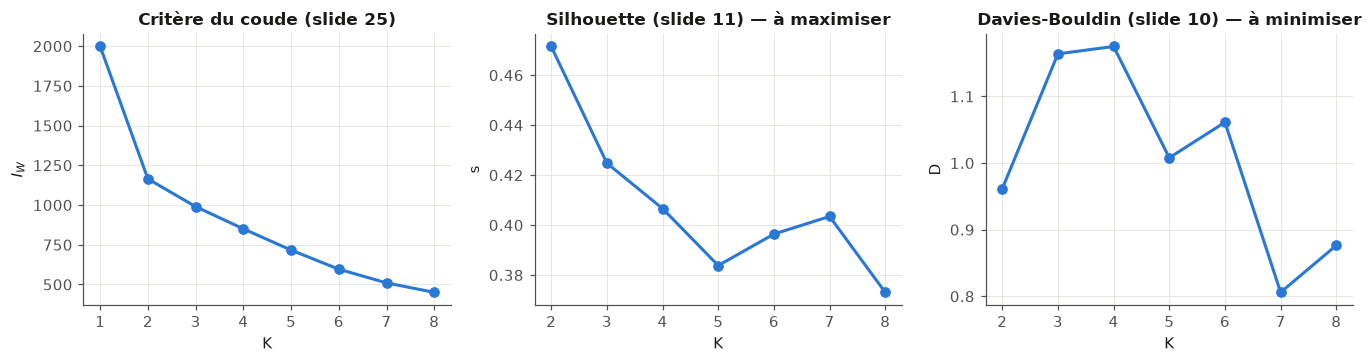

   inertie intra I_W  silhouette s  Davies-Bouldin D                       effectifs
K                                                                                   
2           1164.474         0.471             0.961                       [143, 80]
3            989.784         0.425             1.164                   [116, 80, 27]
4            850.056         0.407             1.175               [116, 61, 27, 19]
5            716.380         0.384             1.008            [60, 60, 59, 25, 19]
6            595.994         0.396             1.061         [58, 58, 54, 24, 22, 7]
7            509.879         0.403             0.806      [60, 59, 58, 24, 19, 2, 1]
8            450.348         0.373             0.876  [59, 58, 39, 24, 22, 18, 2, 1]


In [10]:

from sklearn.metrics import silhouette_score, davies_bouldin_score

Ks = range(2, 9)
crit = []
for K in Ks:
    km = KMeans(n_clusters=K, n_init=20, random_state=0).fit(X_np)
    crit.append({"K": K, "inertie intra I_W": km.inertia_,
                 "silhouette s": silhouette_score(X_np, km.labels_),
                 "Davies-Bouldin D": davies_bouldin_score(X_np, km.labels_),
                 "effectifs": sorted(np.bincount(km.labels_), reverse=True)})
crit = pd.DataFrame(crit).set_index("K")
iw_total = float(((X_np - X_np.mean(axis=0)) ** 2).sum())        # K=1 : inertie totale

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
axes[0].plot([1, *Ks], [iw_total, *crit["inertie intra I_W"]], marker="o",
             color=theme_viz.SERIES[0])
axes[0].set_title("Critère du coude (slide 25)")
axes[0].set_xlabel("K"); axes[0].set_ylabel("$I_W$")
axes[1].plot(list(Ks), crit["silhouette s"], marker="o", color=theme_viz.SERIES[0])
axes[1].set_title("Silhouette (slide 11) — à maximiser")
axes[1].set_xlabel("K"); axes[1].set_ylabel("s")
axes[2].plot(list(Ks), crit["Davies-Bouldin D"], marker="o", color=theme_viz.SERIES[0])
axes[2].set_title("Davies-Bouldin (slide 10) — à minimiser")
axes[2].set_xlabel("K"); axes[2].set_ylabel("D")
for ax in axes:
    ax.set_xticks([1, *Ks] if ax is axes[0] else list(Ks))
fig.tight_layout(); plt.show()

print(crit.round(3).to_string())



**Lecture — arbitrage sur $K$.** Les trois critères internes désignent
$K = 2$ (coude marqué : $I_W$ chute de 1 998 à 1 165, puis décroît
régulièrement ; silhouette maximale 0,47 ; Davies-Bouldin minimal 0,96).
Mais cette partition à deux groupes ne fait que **redécouvrir la ligne
métier** promotion / aménagement, déjà lue sur l'axe PC1 — une validation
rassurante de la matrice de profils, pas une information nouvelle pour le
copilote. C'est le cas prévu par le cours : l'évaluation interne ne suffit
pas, il faut une **évaluation externe, a posteriori par un expert**
(slide 29). Pour l'usage visé (comparer une opération à ses semblables,
axes A et C), nous descendons d'un niveau et retenons $\mathbf{K = 4}$ : la
silhouette reste correcte (0,41) et c'est la granularité la plus fine où
chaque groupe conserve un effectif substantiel (19 à 116 opérations) et une
signature de coûts nettement distincte — au-delà, les critères se dégradent
sans gain d'interprétation (à $K=7$-8, Davies-Bouldin s'améliore mais la
silhouette chute et des groupes anecdotiques apparaissent).



## 6. CAH avec la distance de Ward

La classification ascendante hiérarchique (slide 15) part de $n$ clusters
singletons et agglomère à chaque étape les deux clusters les plus proches.
Parmi les distances entre clusters (slide 16), nous retenons la **distance
de Ward** (slide 17) :

$$d(C_k, C_\ell) = \frac{|C_k|\,|C_\ell|}{|C_k| + |C_\ell|}\,\|\mu_k - \mu_\ell\|^2,$$

qui, d'après la proposition du cours, correspond exactement à la **perte
d'inertie inter-classes** (= gain d'inertie intra) provoquée par la fusion
de $C_k$ et $C_\ell$ — dans la décomposition $I = I_W + I_B$ de la slide 12.
La CAH-Ward est donc l'homologue glouton et hiérarchique des K-moyennes :
les deux minimisent l'inertie intra-classes, l'une par fusions
irrévocables en $O(dn^2)$ par itération (slide 19), l'autre par
réaffectations itératives en $O(ndKt)$ (slide 26). Comparer leurs
partitions est un test de **stabilité** de la typologie (slide 29).


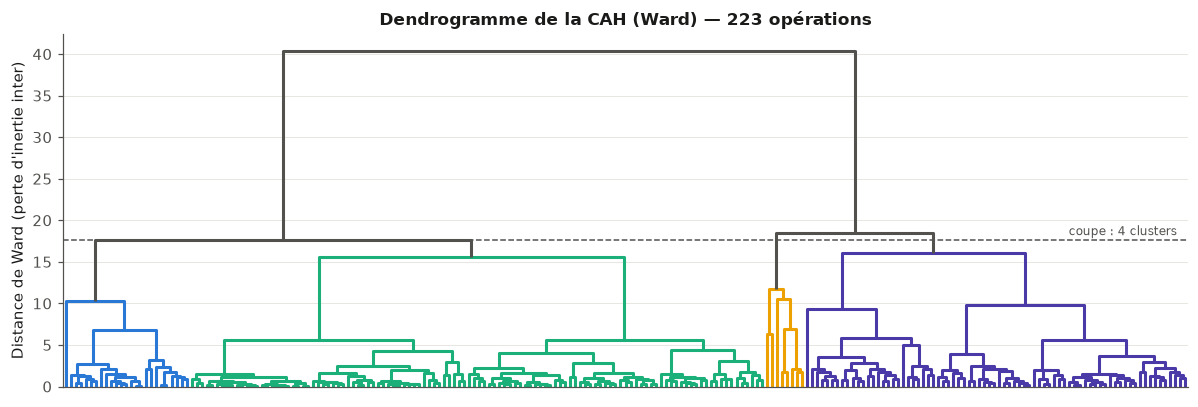

CAH-Ward (4 classes)   1    2  3   4
K-moyennes (K=4)                    
0                     25    0  2   0
1                      0    0  4  57
2                      0    0  0  19
3                      0  114  2   0



Indice de Rand ajusté K-moyennes / CAH : 0.862


In [11]:

from scipy.cluster import hierarchy

Z = hierarchy.linkage(X_np, method="ward")       # CAH, distance de Ward
seuil = float(Z[-3, 2]) - 1e-9                   # hauteur de coupe -> 4 clusters

hierarchy.set_link_color_palette(list(theme_viz.SERIES))
fig, ax = plt.subplots(figsize=(11, 3.8))
hierarchy.dendrogram(Z, no_labels=True, color_threshold=seuil,
                     above_threshold_color=theme_viz.ENCRE_2, ax=ax)
ax.axhline(seuil, color=theme_viz.ENCRE_2, lw=1, ls="--")
ax.text(0.99, seuil * 1.03, "coupe : 4 clusters", transform=ax.get_yaxis_transform(),
        ha="right", fontsize=8, color=theme_viz.ENCRE_2)
ax.set_title("Dendrogramme de la CAH (Ward) — 223 opérations")
ax.set_ylabel("Distance de Ward (perte d'inertie inter)")
plt.tight_layout(); plt.show()

cah4 = hierarchy.fcluster(Z, t=4, criterion="maxclust")
table = pd.crosstab(pd.Series(km4.labels_, name="K-moyennes (K=4)"),
                    pd.Series(cah4, name="CAH-Ward (4 classes)"))
print(table.to_string())
print(f"\nIndice de Rand ajusté K-moyennes / CAH : "
      f"{adjusted_rand_score(km4.labels_, cah4):.3f}")



**Lecture.** Le dendrogramme raconte la même histoire que l'ACP : la
première scission (tout en haut) sépare promotion et aménagement, puis
chaque branche se subdivise. La table de contingence montre un accord fort
entre les deux algorithmes (indice de Rand ajusté ≈ 0,86, version ajustée
de l'indice de Rand cité slide 29) : chaque cluster K-moyennes correspond
massivement à une classe CAH, les désaccords se limitant à quelques
opérations frontière que la CAH, gloutonne et irrévocable, affecte
différemment. La typologie à 4 groupes est **stable au changement
d'algorithme** — le critère de robustesse de la slide 29.



## 7. Interprétation métier : nommer les types d'opérations

Dernière étape du cours (slide 29) : l'**évaluation externe** par
l'expertise métier. On caractérise chaque cluster K-moyennes par son profil
de coûts moyen, puis on le croise avec des variables **absentes de la
matrice $X$** : activité, agence, marge relative budgétée, taux de
désistement (table `ventes`), littoral (table `communes`), taille. Si ces
variables externes s'organisent proprement selon les clusters, la typologie
capture une réalité métier et non un artefact numérique.


In [12]:

ventes = pd.read_sql("SELECT id_operation, desiste FROM ventes", con)
desist = ventes.groupby("id_operation")["desiste"].mean()
littoral = pd.read_sql("""
    SELECT o.id_operation, c.littoral
    FROM operations o JOIN communes c ON o.commune_norm = c.commune_norm
""", con).set_index("id_operation")["littoral"]

def nommer(profil: pd.Series) -> str:
    """Nom métier d'un cluster d'après son profil de coûts moyen."""
    dominant = profil.idxmax()
    if dominant == "CONSTRUCTION":
        return ("Résidentiel classique" if profil["FONCIER"] >= 0.12
                else "Promotion sur foncier allégé")
    if dominant == "FONCIER":
        return "Aménagement foncier"
    return "Aménagement lourd (VRD & taxes)"

clu = pd.Series(km4.labels_, index=P.index, name="cluster")
lignes, profils_moyens = [], {}
for k in sorted(clu.unique(), key=lambda k: -(clu == k).sum()):
    idx = clu[clu == k].index
    profil = P.loc[idx].mean()
    nom = nommer(profil)
    profils_moyens[nom] = profil
    top = profil.sort_values(ascending=False).head(3)
    lignes.append({
        "type": nom, "n": len(idx),
        "postes dominants": ", ".join(f"{i.title()} {v:.0%}" for i, v in top.items()),
        "activité maj.": ops.loc[idx, "activite"].mode()[0],
        "agence maj.": ops.loc[idx, "agence"].str.replace("AMENAGEMENT / ", "", regex=False)
                          .str.strip().mode()[0],
        "marge rel. médiane": f"{marge_rel[idx].median():+.1%}",
        "taux désistement": f"{desist.reindex(idx).mean():.1%}",
        "% littoral": f"{littoral.reindex(idx).mean():.0%}",
        "recettes méd. (M€)": round(marge.loc[idx, "recettes_budget"].median() / 1e6, 1),
    })
typologie = pd.DataFrame(lignes).set_index("type")
typologie


,n,postes dominants,activité maj.,agence maj.,marge rel. médiane,taux désistement,% littoral,recettes méd. (M€)
type,,,,,,,,
Résidentiel classique,116,"Construction 58%, Foncier 14%, Gestion 8%",Promotion,Agence Béziers,+8.2%,12.0%,17%,6.3
Aménagement foncier,61,"Foncier 39%, Vrd 33%, Commercialisation 9%",Amenagement,Agence Béziers,+13.2%,1.1%,9%,2.7
Promotion sur foncier allégé,27,"Construction 57%, Vrd 10%, Foncier 9%",Promotion,Agence Salon-de-Provence,+7.0%,0.2%,8%,5.1
Aménagement lourd (VRD & taxes),19,"Vrd 35%, Foncier 25%, Taxes 16%",Amenagement,Agence Béziers,+14.4%,4.8%,38%,7.2


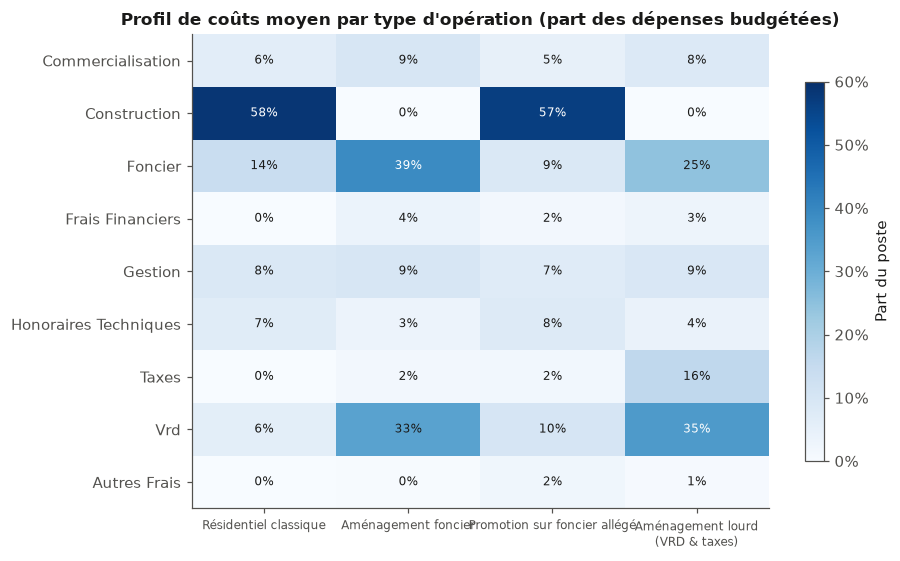

In [13]:

prof = pd.DataFrame(profils_moyens)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
im = ax.imshow(prof.to_numpy(), cmap=theme_viz.CMAP_SEQ, vmin=0, vmax=0.6, aspect="auto")
ax.set_xticks(range(prof.shape[1]),
              [c.replace(" (", "\n(") for c in prof.columns], fontsize=8)
ax.set_yticks(range(prof.shape[0]), [i.title() for i in prof.index])
for i in range(prof.shape[0]):
    for j in range(prof.shape[1]):
        v = prof.iloc[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8,
                color="white" if v > 0.35 else theme_viz.ENCRE)
ax.set_title("Profil de coûts moyen par type d'opération (part des dépenses budgétées)")
ax.grid(False)
fig.colorbar(im, shrink=0.8, format=lambda x, _: f"{x:.0%}", label="Part du poste")
plt.tight_layout(); plt.show()



**Lecture — la typologie, validée par les variables externes.**

- **Résidentiel classique** (n = 116) : promotion pure — `CONSTRUCTION`
  58 %, `FONCIER` 14 % — portée par Béziers, Perpignan et Montpellier ;
  marge relative médiane +8,2 %, mais **taux de désistement moyen de 12 %**,
  le plus élevé : c'est le segment exposé à la conjoncture du crédit
  (axe B).
- **Aménagement foncier** (n = 61) : le lotissement type — `FONCIER` 39 %,
  `VRD` 33 % ; marge médiane +13,2 %, désistements quasi nuls (1,1 %) : on
  vend des terrains viabilisés, souvent sans crédit long.
- **Promotion sur foncier allégé** (n = 27) : promotion atypique —
  `CONSTRUCTION` 57 % mais `FONCIER` réduit à 9 % et `VRD` gonflé à 10 % ;
  surreprésentation de Salon-de-Provence. Profil cohérent avec des
  opérations bâties sur des terrains déjà maîtrisés (macro-lots des propres
  ZAC du groupe) ; marge médiane +7,0 %, la plus mince : le foncier
  « économisé » ne se retrouve pas en marge, un point à instruire pour
  l'axe A.
- **Aménagement lourd (VRD & taxes)** (n = 19) : `VRD` 35 %, `TAXES` 16 % ;
  **38 % d'opérations littorales** (contre 9 % pour l'aménagement courant)
  et recettes médianes les plus fortes (7,2 M€) : grands aménagements de
  stations et zones littorales, lourdement taxés et équipés, marge médiane
  +14,4 % — la plus confortable, en contrepartie d'un portage long.

Les variables externes (marge, désistements, littoral, agence) s'ordonnent
nettement selon les clusters alors qu'aucune n'a servi à les construire :
au sens de la slide 29, l'évaluation externe valide la typologie.



## 8. Synthèse : ce que la typologie apporte au copilote

1. **Un comparateur opérationnel (B-A3)** : la similarité cosinus sur
   profils standardisés fournit, pour toute opération, ses $k$ plus
   proches voisines et leur marge — l'exemple du *Parc des Cyclades*
   (marge budgétée 2 à 5 points sous ses cinq semblables) montre le réflexe
   de revue de gestion que la plateforme automatisera.
2. **Quatre types d'opérations nommés et stables** (K-moyennes = CAH-Ward
   à un indice de Rand ajusté de 0,86) : résidentiel classique,
   aménagement foncier, promotion sur foncier allégé, aménagement lourd
   VRD & taxes.
3. **Pour l'axe A (risque de marge)** : le type d'opération devient une
   variable explicative candidate du notebook 03 — les niveaux de marge et
   de désistement diffèrent structurellement d'un type à l'autre ; comparer
   la dérive d'une opération à celle de son type évitera de confondre effet
   de structure et dérive réelle.
4. **Pour l'axe C (prix)** : le modèle hédonique pourra être contrôlé par
   type ; les voisines au sens du cosinus donnent un référentiel de prix
   par segment.
5. **Méthode** : ACP validée par le SVD à $10^{-15}$ près (même objet
   mathématique, *regularization.pdf* p. 26) ; critères internes de choix
   de $K$ confrontés à l'évaluation externe (slide 29) — les critères
   désignaient $K=2$, l'expertise métier impose $K=4$ ; contrainte
   compositionnelle ($\lambda_9 = 0$) détectée par l'ACP.

**Limites.** La typologie repose sur le budget **initial** (structure des
coûts prévue, pas réalisée) ; les opérations embryonnaires (< 1 M€) en sont
exclues et devront être rattachées à un type par leur profil prévisionnel ;
le choix $K=4$ reste un arbitrage d'expertise, documenté et réversible.

**Suite** : notebook 03 — axe A, régression régularisée et classification
du risque de marge, où les types construits ici entrent comme variables.
